# Giải thích `Core/Imu.hpp` của LIMOncello

Notebook này giải thích riêng file `Imu.hpp` của LIMOncello.

Dù file rất ngắn, nó là **gói dữ liệu IMU chuẩn** mà backend IESEKF dùng ở mọi bước dự đoán:

- `stamp`: thời gian của mẫu IMU,
- `ang_vel`: vận tốc góc từ gyroscope,
- `lin_accel`: gia tốc tuyến tính đo được từ accelerometer,
- `q`: quaternion định hướng đi kèm mẫu IMU.

Mục tiêu của notebook này là nối **từng dòng code** với:

1. vai trò của IMU trong pipeline LiDAR–Inertial,
2. phương trình đo IMU trong paper,
3. cách `State::predict()` biến mẫu IMU thành increment trên `SGal(3)`,
4. các chỗ người mới rất dễ hiểu nhầm, đặc biệt là **gravity**, **frame**, và **quaternion**.


## 0. Đoạn code cần đọc

```cpp
#pragma once

#include <Eigen/Dense>

#include "Utils/Config.hpp"

struct Imu {
  double stamp;
  Eigen::Vector3d ang_vel;
  Eigen::Vector3d lin_accel;
  Eigen::Quaterniond q;

  Imu() : stamp(0.),
          ang_vel(Eigen::Vector3d::Zero()),
          lin_accel(Eigen::Vector3d::Zero()),
          q(Eigen::Quaterniond::Identity()) {}
};
```

## 1. Bức tranh lớn: file này đứng ở đâu trong LIMOncello?

Trong pipeline của paper, **IMU chạy liên tục giữa hai frame LiDAR** để:

- dự đoán state ở tần số cao,
- lưu các pose trung gian để deskew từng điểm,
- cung cấp prior cho bước update bằng LiDAR.

`Imu.hpp` chính là **container cho một mẫu IMU** đi vào chuỗi đó.

Nếu nói bằng ngôn ngữ đời thường thì file này chỉ làm một việc:

> gom tất cả thông tin cần cho **một lần predict()** vào một struct rất gọn.

Vì backend của LIMOncello dùng IMU làm nguồn dự đoán chính, nên dù file chỉ vài dòng, nó là điểm vào của toàn bộ phần propagation.


## 2. Liên hệ với công thức trong paper

Paper mô hình hóa đo IMU bằng hai phương trình:

\[
\omega_m = \omega^\star + b_\omega + n_\omega
\]

\[
a_m = a^\star + b_a + n_a - R^\top g
\]

Ý nghĩa của chúng:

- `ang_vel` trong code tương ứng với **gyroscope measurement** \( \omega_m \),
- `lin_accel` trong code tương ứng với **accelerometer measurement** \( a_m \),
- đây là **đại lượng đo được**, chưa phải state đã hiệu chỉnh bias và gravity.

Trong implementation hiện tại, `State::predict()` lấy đúng hai trường này rồi mới trừ bias và xử lý gravity theo convention của codebase. Vì vậy, khi đọc `Imu.hpp`, hãy nhớ:

\[
\texttt{Imu} \neq \text{state của robot}
\]

mà chỉ là:

\[
\texttt{Imu} = \text{một gói đo cảm biến tại thời điểm } t_k.
\]

> Ghi chú quan trọng về dấu gravity: paper và code hiện tại dùng convention có thể làm bạn thấy dấu khác nhau nếu chỉ nhìn công thức một cách máy móc. Vì thế ở notebook này mình bám vào **code thật** của `State.hpp` khi nói về bước hiệu chỉnh gravity.


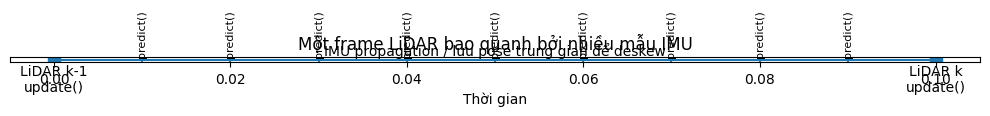

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Hình minh hoạ: IMU chạy dày đặc giữa hai frame LiDAR
t0, t1 = 0.0, 0.1
imu_times = np.linspace(t0, t1, 11)
lidar_times = [t0, t1]

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.hlines(0, t0, t1, linewidth=1.5)
ax.vlines(imu_times, -0.12, 0.12)
ax.scatter(lidar_times, [0, 0], s=80, marker='s')
ax.set_yticks([])
ax.set_xlabel("Thời gian")
ax.set_title("Một frame LiDAR bao quanh bởi nhiều mẫu IMU")

for t in imu_times[1:-1]:
    ax.text(t, 0.16, "predict()", ha="center", va="bottom", fontsize=8, rotation=90)

ax.text(t0, -0.22, "LiDAR k-1\nupdate()", ha="center", va="top")
ax.text(t1, -0.22, "LiDAR k\nupdate()", ha="center", va="top")
ax.text((t0+t1)/2, 0.28, "IMU propagation / lưu pose trung gian để deskew", ha="center")

ax.set_xlim(t0 - 0.005, t1 + 0.005)
plt.tight_layout()
plt.show()


## 3. Giải thích từng field trong `struct Imu`

### 3.1 `double stamp;`

Đây là **timestamp** của mẫu IMU.

Nó quan trọng vì backend cần:

- biết mẫu này xảy ra lúc nào,
- tính \(dt\) giữa hai mẫu liên tiếp,
- nội suy state đến timestamp của từng điểm LiDAR khi deskew.

Nếu timestamp sai hoặc lệch time base giữa LiDAR và IMU, toàn bộ propagation sẽ bị sai.

---

### 3.2 `Eigen::Vector3d ang_vel;`

Đây là vận tốc góc 3 trục từ gyroscope:

\[
\omega_m =
\begin{bmatrix}
\omega_x \\ \omega_y \\ \omega_z
\end{bmatrix}
\]

Đơn vị chuẩn là **rad/s**.

Nó mô tả robot đang quay nhanh thế nào quanh các trục của **IMU frame / body frame**.

---

### 3.3 `Eigen::Vector3d lin_accel;`

Đây là đo accelerometer:

\[
a_m =
\begin{bmatrix}
a_x \\ a_y \\ a_z
\end{bmatrix}
\]

Đơn vị chuẩn là **m/s²**.

Điểm rất dễ nhầm:

- đây **không phải** vận tốc,
- cũng **không hẳn** là “gia tốc động học thuần”,
- nó là số đo accelerometer, nên thường **đã lẫn gravity**, bias và noise theo convention của hệ thống.

---

### 3.4 `Eigen::Quaterniond q;`

Đây là quaternion mô tả orientation đi kèm mẫu IMU:

\[
q = [w, x, y, z], \qquad \|q\| = 1.
\]

Quaternion là cách biểu diễn rotation gọn, không bị singularity kiểu Euler angle.

Điểm rất quan trọng khi đọc code LIMOncello:

- `q` **có mặt trong `Imu` struct**,
- nhưng trong `State::predict()` hiện tại, backend **chỉ dùng** `imu.lin_accel` và `imu.ang_vel`,
- `q` **không được dùng trực tiếp** để propagate state trong file `State.hpp` hiện tại.

Nghĩa là: file này lưu cả orientation nếu có, nhưng backend prediction của LIMOncello hiện đang đi theo hướng **propagate từ gyro + accel**, không phải “tin luôn quaternion từ IMU”.


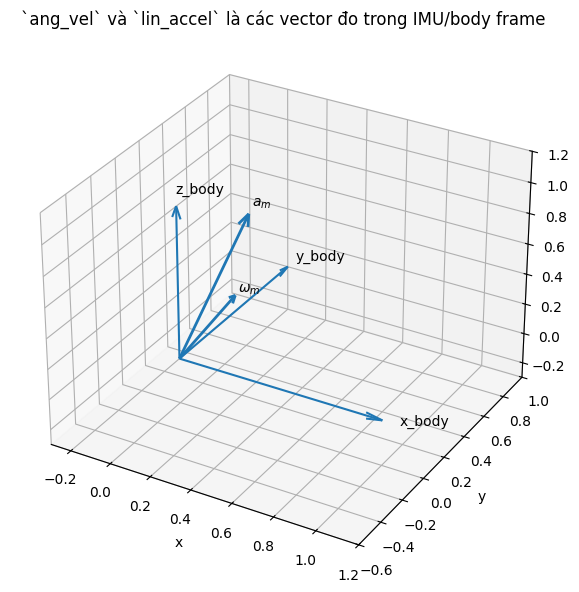

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Hình minh hoạ: vector đo trong body frame
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

origin = np.zeros(3)
basis = np.eye(3)

# Axes của body frame
for v, label in zip(basis, ["x_body", "y_body", "z_body"]):
    ax.quiver(*origin, *v, arrow_length_ratio=0.08)
    ax.text(*(1.08*v), label)

# Ví dụ một đo gyro và accel
omega = np.array([0.4, -0.2, 0.7])
accel = np.array([0.3, 0.1, 1.0])

ax.quiver(*origin, *omega, arrow_length_ratio=0.08, linewidth=2)
ax.text(*(1.05*omega), r"$\omega_m$")

ax.quiver(*origin, *accel, arrow_length_ratio=0.08, linewidth=2)
ax.text(*(1.05*accel), r"$a_m$")

ax.set_title("`ang_vel` và `lin_accel` là các vector đo trong IMU/body frame")
ax.set_xlim(-0.3, 1.2)
ax.set_ylim(-0.6, 1.0)
ax.set_zlim(-0.3, 1.2)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.tight_layout()
plt.show()


## 4. Constructor mặc định đang làm gì?

```cpp
Imu() : stamp(0.),
        ang_vel(Eigen::Vector3d::Zero()),
        lin_accel(Eigen::Vector3d::Zero()),
        q(Eigen::Quaterniond::Identity()) {}
```

Đây là cách khởi tạo một mẫu IMU “an toàn”:

- `stamp = 0.`: chưa có thời gian thực sự,
- `ang_vel = 0`: chưa có quay,
- `lin_accel = 0`: chưa có gia tốc đo,
- `q = Identity`: orientation mặc định là không quay.

Vì sao cách này hợp lý?

- tránh để biến rác trong bộ nhớ,
- giúp tạo `Imu imu;` rồi gán dần từng trường,
- khi debug rất dễ biết field nào chưa được điền.

Lưu ý nhỏ: `lin_accel = 0` **không** mang nghĩa “robot đứng yên thật sự”; đó chỉ là **giá trị khởi tạo an toàn**.


## 5. `Imu.hpp` nối vào `State.hpp` như thế nào?

Đây là đoạn quan trọng nhất trong `State.hpp`:

```cpp
  void predict(const Imu& imu, const double& dt) {
PROFC_NODE("predict")

    Mat<DoF> Adj, Jr; // Adjoint_X(u)^{-1}, J_r(u)  Sola-18, [https://arxiv.org/abs/1812.01537]
    BundleT X_tmp = X.plus(f(imu.lin_accel, imu.ang_vel) * dt, Adj, Jr);
    
    // S2 particular cases. No increment for g
      Mat<3> AdjS2, JrS2;
      S2::boxplus(g(), {0., 0., 0.}, AdjS2, JrS2);

      Adj.template bottomRightCorner<3, 3>() = AdjS2;
      Jr.template bottomRightCorner<3, 3>() = JrS2;

      // Leftmost Jacobian
      Mat<2, 3> Jx;
      S2::ominus(g(), g(), Jx);

      Mat<DoFS2, DoF> left = Mat<DoFS2, DoF>::Identity();
      left.template bottomRightCorner<2, 3>() = Jx;
      
      // Rightmost Jacobian
      Mat<3, 2> Ju;
      S2::oplus(g(), {0., 0.}, {}, Ju);

      Mat<DoF, DoFS2> right = Mat<DoF, DoFS2>::Identity();
      right.template bottomRightCorner<3, 2>() = Ju;

    Mat<DoFS2>           Fx = left * (Adj + Jr * df_dx(imu) * dt) * right; // Pérez-Ruiz-2026 [https://arxiv.org/abs/2512.19567] Eq. (8a)
    Mat<DoFS2, DoFNoise> Fw = left * Jr * df_dw() * dt;                    // Pérez-Ruiz-2026 [https://arxiv.org/abs/2512.19567] Eq. (8b)

    P = Fx * P * Fx.transpose() + Fw * Q * Fw.transpose(); 

    X = X_tmp;

    // Save info
    a = imu.lin_accel;
    w = imu.ang_vel;

    stamp = imu.stamp;
  }


  void interpolate_to(const double& t) {
    double dt = t - this->stamp;
    assert(dt >= 0);

    X = X.plus(f(a, w) * dt);
  }


  Tangent f(const Vec<3>& lin_acc, const Vec<3>& ang_vel) {

    Tangent u = Tangent::Zero();
    u.element<0>().coeffs() << 0., 0., 0., 
                               lin_acc - b_a() /* -n_a */ - R().transpose()*g(),
                               ang_vel - b_w() /* -n_w */,
                               1.;
```

Bạn có thể đọc đoạn này theo đúng 3 ý:

1. `predict()` nhận **một mẫu IMU** và một `dt`.
2. Nó gọi `f(imu.lin_accel, imu.ang_vel)` để tạo increment trên tangent space.
3. Sau khi propagation xong, nó lưu lại `a`, `w` và `stamp` để còn nội suy tiếp bằng `interpolate_to()`.

Nói ngắn gọn:

\[
\texttt{Imu} \;\longrightarrow\; \texttt{predict()} \;\longrightarrow\; \texttt{State}
\]

Trong đó `Imu` là **input**, còn `State` là **thứ được tiến hóa theo thời gian**.


## 6. Công thức từ `Imu` sang increment động học

Phần lõi trong `f()` là:

```cpp
  Tangent f(const Vec<3>& lin_acc, const Vec<3>& ang_vel) {

    Tangent u = Tangent::Zero();
    u.element<0>().coeffs() << 0., 0., 0., 
                               lin_acc - b_a() /* -n_a */ - R().transpose()*g(),
                               ang_vel - b_w() /* -n_w */,
                               1.;
```

Dòng quan trọng nhất là:

\[
u =
\begin{bmatrix}
0 \\
a_m - b_a - R^\top g \\
\omega_m - b_\omega \\
1
\end{bmatrix}
\]

ở mức trực giác.

Đọc công thức này như sau:

- `ang_vel` đi vào phần quay sau khi trừ gyro bias,
- `lin_accel` đi vào phần gia tốc sau khi trừ accel bias và bù gravity theo convention của code,
- `1` ở cuối làm biến thời gian bên trong `SGal(3)` tăng đều.

Điều này cho thấy vì sao `Imu.hpp` chỉ cần 4 trường:

- thời gian mẫu,
- đo gyro,
- đo accel,
- quaternion tùy chọn đi kèm.

Chừng đó đã đủ để backend thực hiện propagation.


In [3]:

import numpy as np

def rot_from_euler(roll, pitch, yaw):
    cr, sr = np.cos(roll), np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw), np.sin(yaw)
    Rx = np.array([[1,0,0],[0,cr,-sr],[0,sr,cr]])
    Ry = np.array([[cp,0,sp],[0,1,0],[-sp,0,cp]])
    Rz = np.array([[cy,-sy,0],[sy,cy,0],[0,0,1]])
    return Rz @ Ry @ Rx

# Ví dụ: IMU đứng yên nhưng có orientation nghiêng nhẹ
R = rot_from_euler(np.deg2rad(10), np.deg2rad(-5), np.deg2rad(20))
g_world = np.array([0.0, 0.0, 9.81])

b_a = np.array([0.08, -0.03, 0.05])
b_w = np.array([0.01, -0.02, 0.005])

true_omega = np.array([0.0, 0.0, 0.0])   # đứng yên
omega_meas = true_omega + b_w

# Theo convention của code: nếu đứng yên thì a_meas ≈ b_a + R^T g
a_meas = b_a + R.T @ g_world

a_used_by_filter = a_meas - b_a - R.T @ g_world
w_used_by_filter = omega_meas - b_w

print("Gyro đo được omega_meas =", np.round(omega_meas, 4))
print("Gyro sau khi trừ bias   =", np.round(w_used_by_filter, 8))
print()
print("Accel đo được a_meas    =", np.round(a_meas, 4))
print("Accel sau bù bias+g     =", np.round(a_used_by_filter, 8))


Gyro đo được omega_meas = [ 0.01  -0.02   0.005]
Gyro sau khi trừ bias   = [0. 0. 0.]

Accel đo được a_meas    = [0.935  1.667  9.6742]
Accel sau bù bias+g     = [0. 0. 0.]


### Ý nghĩa của ví dụ trên

Nếu IMU **đang đứng yên** và ta dùng đúng bias + gravity theo convention của code, thì sau bước hiệu chỉnh:

\[
\omega_m - b_\omega \approx 0
\]
\[
a_m - b_a - R^\top g \approx 0
\]

Đây là trực giác vật lý rất quan trọng:

- khi robot không quay, vận tốc góc sau khi trừ bias phải gần 0;
- khi robot không có gia tốc động học, accelerometer sau khi bỏ bias và gravity cũng phải gần 0.

Vì vậy, `Imu.hpp` lưu **đo thô**, còn `State::f()` mới là nơi chuyển chúng thành đại lượng động học có ý nghĩa cho filter.


## 7. Quaternion `q` có ý nghĩa gì?

Một quaternion đơn vị biểu diễn rotation. Nếu viết vector \(v\) thành quaternion thuần \([0, v]\), thì vector sau khi quay là:

\[
v' = q \, v \, q^{-1}.
\]

Trong thực hành với Eigen, ta thường dùng quaternion để tạo rotation matrix hoặc quay trực tiếp vector.

Điều cần nhớ ở file này:

- `q` là **metadata hữu ích** đi kèm mẫu IMU,
- nó không làm propagation thay cho gyro trong `State.hpp`,
- nhưng vẫn đáng lưu vì nhiều IMU / driver / pipeline trung gian có thể cung cấp orientation ước lượng sẵn.

Nói cách khác:

> `q` trong `Imu` là **thông tin có thể có**, còn prediction backend hiện tại của LIMOncello vẫn bám vào **gyro + accel**.


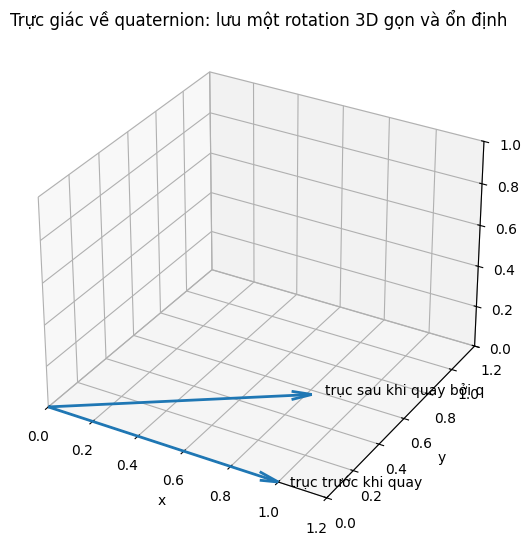

In [4]:

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def quat_from_axis_angle(axis, angle):
    axis = np.asarray(axis, dtype=float)
    axis = axis / np.linalg.norm(axis)
    w = np.cos(angle/2)
    xyz = axis * np.sin(angle/2)
    return np.r_[w, xyz]

def quat_mul(q1, q2):
    w1,x1,y1,z1 = q1
    w2,x2,y2,z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ])

def quat_conj(q):
    return np.array([q[0], -q[1], -q[2], -q[3]])

def rotate_vec(q, v):
    vq = np.r_[0.0, v]
    return quat_mul(quat_mul(q, vq), quat_conj(q))[1:]

q = quat_from_axis_angle([0, 0, 1], np.deg2rad(35))
v = np.array([1.0, 0.0, 0.0])
v_rot = rotate_vec(q, v)

fig = plt.figure(figsize=(6.5, 5.5))
ax = fig.add_subplot(111, projection='3d')
origin = np.zeros(3)

ax.quiver(*origin, *v, arrow_length_ratio=0.08, linewidth=2)
ax.text(*(1.05*v), "trục trước khi quay")

ax.quiver(*origin, *v_rot, arrow_length_ratio=0.08, linewidth=2)
ax.text(*(1.05*v_rot), "trục sau khi quay bởi q")

ax.set_title("Trực giác về quaternion: lưu một rotation 3D gọn và ổn định")
ax.set_xlim(0, 1.2)
ax.set_ylim(0, 1.2)
ax.set_zlim(0, 1.0)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.tight_layout()
plt.show()


## 8. Line-by-line annotate cực ngắn

### `#pragma once`
Header guard hiện đại: tránh include lặp.

### `#include <Eigen/Dense>`
Để có `Eigen::Vector3d` và `Eigen::Quaterniond`.

### `#include "Utils/Config.hpp"`
Trong phiên bản hiện tại của file này, include này **không được dùng trực tiếp** bên trong `struct Imu`, nhưng vẫn xuất hiện trong header.

### `struct Imu`
Một plain data structure rất nhẹ để chở dữ liệu IMU.

### `double stamp;`
Mốc thời gian của mẫu.

### `Eigen::Vector3d ang_vel;`
Gyroscope 3 trục.

### `Eigen::Vector3d lin_accel;`
Accelerometer 3 trục.

### `Eigen::Quaterniond q;`
Quaternion orientation đi kèm mẫu.

### Constructor mặc định
Khởi tạo mọi field về giá trị an toàn và dễ đoán.


## 9. Những chỗ người mới hay hiểu nhầm

1. **`lin_accel` không phải vận tốc.**  
   Nó là số đo accelerometer.

2. **Accelerometer không “tự bỏ gravity”.**  
   Gravity phải được xử lý ở bước mô hình động học / convention của filter.

3. **Có `q` không có nghĩa là filter dùng orientation của IMU để propagate.**  
   Trong `State.hpp` hiện tại, phần prediction dùng `ang_vel` và `lin_accel`.

4. **`stamp` không chỉ để log.**  
   Nó quyết định `dt`, nội suy, deskew và đồng bộ LiDAR–IMU.

5. **Đơn vị rất quan trọng.**  
   `ang_vel` phải là rad/s, không phải deg/s; `lin_accel` phải là m/s².

6. **Frame cũng quan trọng.**  
   README của repo nói IMU frame được dùng như robot frame trong Kalman filter; nếu quy ước trục bị sai, mọi thứ phía sau sẽ sai theo.


## 10. Tóm lại bằng một câu

`Imu.hpp` là **gói dữ liệu tối thiểu cho một mẫu IMU**: thời gian, gyro, accelerometer, quaternion; rồi `State::predict()` dùng mẫu đó để tạo increment động học trên `SGal(3)`.

Nếu bạn nhớ đúng một điều từ notebook này, hãy nhớ điều này:

\[
\boxed{
\texttt{Imu} = \text{mẫu đo cảm biến}
\quad\neq\quad
\text{state của robot}
}
\]

Chính `State.hpp` mới là nơi các số đo đó được:

- trừ bias,
- bù gravity theo convention của code,
- đẩy vào manifold để dự đoán state.


## 11. Nguồn để đối chiếu khi đọc tiếp

Khi học tiếp LIMOncello, bạn nên mở song song 3 file / tài liệu:

1. `include/Core/Imu.hpp`  
   để biết mẫu IMU có gì.

2. `State.hpp`  
   để thấy `predict()` tiêu thụ mẫu IMU ra sao.

3. paper LIMOncello, đặc biệt:
   - phần **Prediction**,
   - Eq. (14) cho IMU measurements,
   - Eq. (15)–(16) cho propagation.

Như vậy bạn sẽ thấy rất rõ đường đi:

\[
\text{IMU packet} \to \texttt{Imu} \to \texttt{predict()} \to \text{SGal(3) propagation}
\]
